<a href="https://colab.research.google.com/github/aaneesa/SectionD_Gr18_Spotify-User-Behavior-And-Pattern/blob/main/notebooks/04_statistical_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency, mannwhitneyu
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

Load Data

In [ ]:
df = pd.read_csv('final_cleaned_spotify_data (1).csv')

print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset: 49,834 rows x 29 columns


,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,is_churned,ad_interaction,ad_conversion_to_subscription,...,is_outlier,age_group,engagement_level,likely_churned,adjusted_status,tenure_months,tenure_bucket,customer_type,Final_status,engagement_score
0,1,france,25,2021-08-19,Premium Duo,Active,0,0,No,No,...,False,25-34,Medium,0,Active,56.866667,Loyal,Loyal,Active,0.474386
1,2,indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,...,False,18-24,Medium,0,Active,47.166667,Loyal,Loyal,Active,0.530416
2,3,italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,...,False,45-54,Medium,0,Active,27.933333,Loyal,Loyal,Active,0.434899
3,4,italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,...,False,45-54,High,1,Likely Churned,93.166667,Loyal,Loyal,Likely Churned,0.651547
4,5,australia,18,2020-05-29,Free,Active,0,0,No,No,...,False,<18,High,0,Active,71.766667,Loyal,Loyal,Active,0.618463


Test 1: Listening Hours

In [ ]:
churned = df[df['is_churned'] == 1]['avg_listening_hours_per_week']
active = df[df['is_churned'] == 0]['avg_listening_hours_per_week']

t_stat, p_val = ttest_ind(churned, active)

print("Mean Listening Hours (Churned):", churned.mean())
print("Mean Listening Hours (Active):", active.mean())
print("T-stat:", t_stat)
print("P-value:", p_val)

Mean Listening Hours (Churned): 9.9467857787403
Mean Listening Hours (Active): 9.94932519611891
T-stat: -0.06024144891185755
P-value: 0.9519635757573195


Test 2: Skips per Day — Do churned users skip more?

In [ ]:
churned_skip = df[df['is_churned']==1]['avg_skips_per_day']
active_skip = df[df['is_churned']==0]['avg_skips_per_day']

u_stat, p_val = mannwhitneyu(churned_skip, active_skip, alternative='greater')

print("Median Skips (Churned):", churned_skip.median())
print("Median Skips (Active):", active_skip.median())
print("P-value:", p_val)

Median Skips (Churned): 10.0
Median Skips (Active): 10.0
P-value: 0.473017137633892


Test 3: Subscription Type vs Churn

In [ ]:
cont = pd.crosstab(df['subscription_type'], df['is_churned'])

chi2, p, dof, exp = chi2_contingency(cont)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 2.8342189731201275
P-value: 0.585940466640738


Test 4: Primary Device vs Churn

In [ ]:
cont2 = pd.crosstab(df['primary_device'], df['is_churned'])

chi2, p, dof, exp = chi2_contingency(cont2)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 4.900370680268382
P-value: 0.2976736910928724


Test 5: Ads Conversion vs Churn

In [ ]:
cont3 = pd.crosstab(df['ad_conversion_to_subscription'], df['is_churned'])

chi2, p, dof, exp = chi2_contingency(cont3)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 0.03888460499966402
P-value: 0.8436774492469541


Feature Importance Analysis

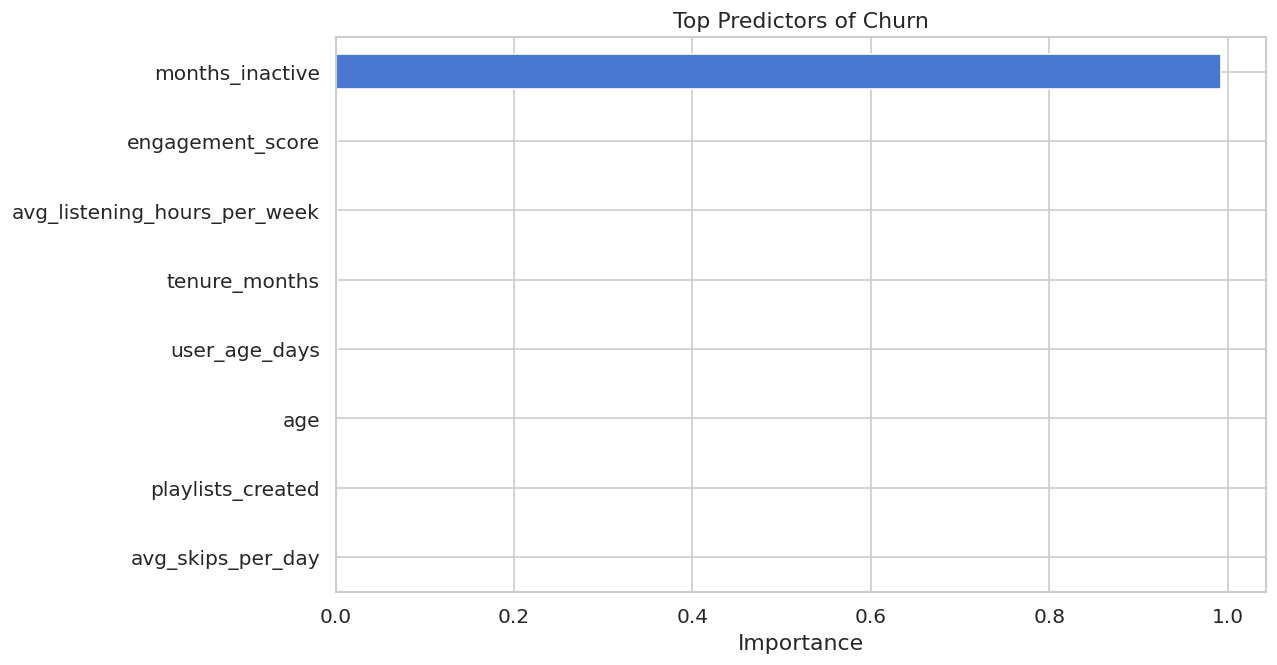

months_inactive                 0.993039
engagement_score                0.001256
avg_listening_hours_per_week    0.001229
tenure_months                   0.001114
user_age_days                   0.001086
age                             0.000841
playlists_created               0.000720
avg_skips_per_day               0.000716
dtype: float64


In [ ]:
feature_cols = [
    'age',
    'months_inactive',
    'avg_listening_hours_per_week',
    'playlists_created',
    'avg_skips_per_day',
    'user_age_days',
    'tenure_months',
    'engagement_score'
]

X = df[feature_cols]
y = df['is_churned']

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=feature_cols)
importance = importance.sort_values()

plt.figure(figsize=(10,6))
importance.plot(kind='barh')
plt.title("Top Predictors of Churn")
plt.xlabel("Importance")
plt.show()

print(importance.sort_values(ascending=False))